# SUR 2025/2026 — Publication figures

All plots for `docs/draft.md`. Run top-to-bottom. Outputs inline (retina) +
saved to `docs/figures/` as vector PDF and 300 DPI PNG.

In [21]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

from __future__ import annotations

import pickle
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, PercentFormatter
from scipy.stats import norm
from sklearn.metrics import roc_curve

REPO = Path.cwd() if Path.cwd().name == "project" else Path.cwd().parent
sys.path.insert(0, str(REPO))
FIG   = REPO / "docs" / "figures"
CACHE = REPO / "cache"
FIG.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)


# Muted journal palette (Nature-adjacent). Sober, colorblind-safe, accent
# reserved for the "winner" bar.
C = {
    "blue":   "#1F4E79",   # deep navy — primary
    "orange": "#C7742F",   # burnt amber — image
    "green":  "#3F7A5E",   # forest — fusion / highlight
    "red":    "#A0433B",   # muted crimson
    "purple": "#6D5B97",
    "grey":   "#9CA3AF",   # neutral grey for reference bars
    "ink":    "#333741",   # near-black for text, softer than pure black
    "grid":   "#E5E7EB",   # light grid line
}

mpl.rcParams.update({
    "figure.dpi":           140,
    "savefig.dpi":          300,
    "figure.facecolor":     "white",
    "savefig.facecolor":    "white",
    "font.family":          "sans-serif",
    "font.sans-serif":      ["Inter", "Helvetica Neue", "Helvetica", "Arial",
                             "DejaVu Sans"],
    "mathtext.fontset":     "dejavusans",
    "font.size":            10,
    "axes.titlesize":       11,
    "axes.titleweight":     "regular",
    "axes.titlelocation":   "left",
    "axes.titlepad":        8,
    "axes.labelsize":       9.5,
    "axes.labelcolor":      C["ink"],
    "axes.edgecolor":       "#B0B4BB",
    "text.color":           C["ink"],
    "xtick.color":          C["ink"],
    "ytick.color":          C["ink"],
    "xtick.labelsize":      8.5,
    "ytick.labelsize":      8.5,
    "legend.fontsize":      8.5,
    "legend.frameon":       False,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.linewidth":       0.7,
    "xtick.major.width":    0.7,
    "ytick.major.width":    0.7,
    "xtick.major.size":     3.0,
    "ytick.major.size":     3.0,
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    "lines.linewidth":      1.4,
    "lines.markersize":     4.5,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.04,
    "pdf.fonttype":         42,
    "ps.fonttype":          42,
    "axes.prop_cycle":      mpl.cycler(color=[C["blue"], C["orange"], C["green"],
                                               C["red"], C["purple"]]),
})


def save(fig, name: str) -> None:
    for ext in ("pdf", "png"):
        fig.savefig(FIG / f"{name}.{ext}")

## Figure 1 — Audio: GMM covariance type ablation (E037)

Tied covariance is the single biggest lever in the audio track — 6.3× better
than diagonal at only a marginal increase in parameters, and 32× cheaper than
the overfitting full covariance.

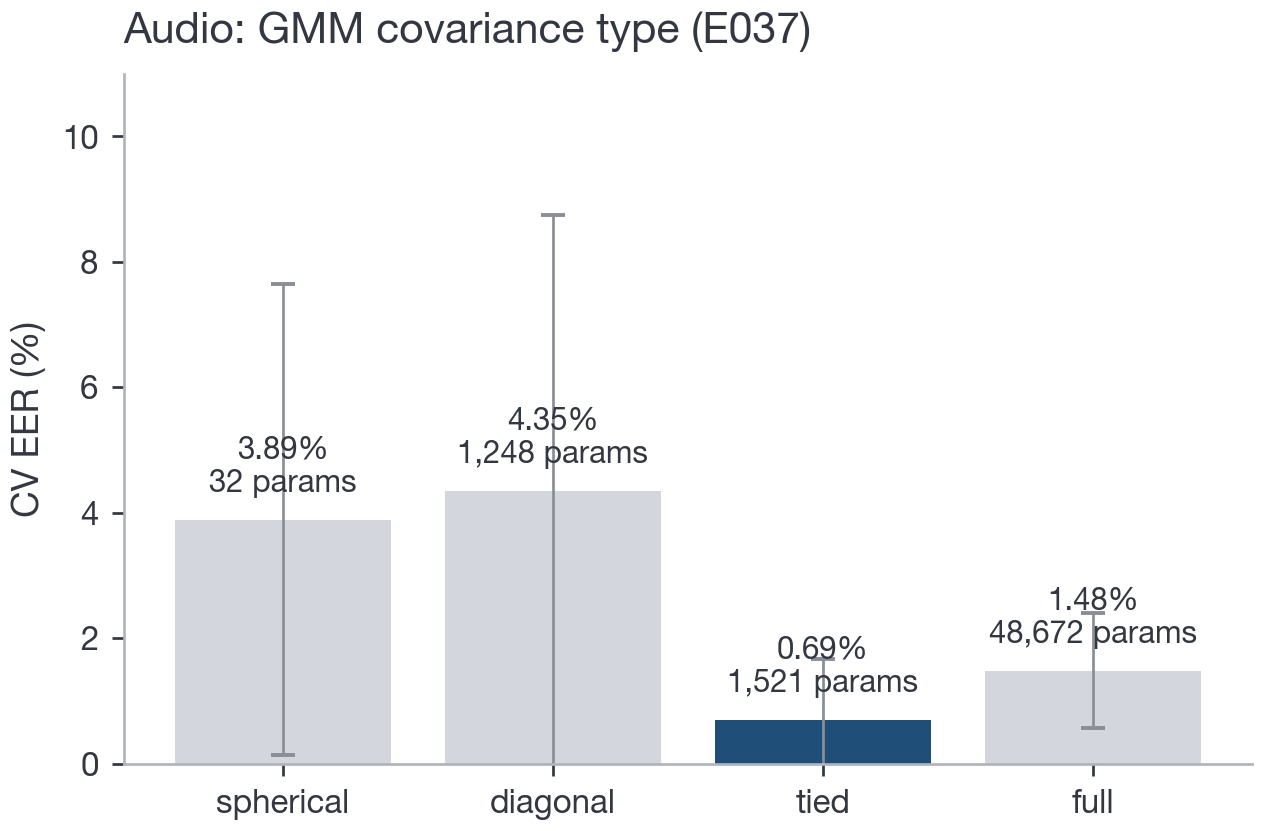

In [22]:
cov_labels = ["spherical", "diagonal", "tied", "full"]
cov_eer    = np.array([3.89, 4.35, 0.69, 1.48])
cov_std    = np.array([3.75, 4.40, 0.98, 0.92])
cov_params = np.array([32, 1248, 1521, 48672])
cov_color  = ["#D3D7DD", "#D3D7DD", C["blue"], "#D3D7DD"]

fig, ax = plt.subplots(figsize=(5.2, 3.2))
bars = ax.bar(cov_labels, cov_eer, yerr=cov_std, color=cov_color,
              edgecolor="none", linewidth=0, capsize=3,
              error_kw={"elinewidth": 0.7, "ecolor": "#8A8F97"})
for bar, eer, n in zip(bars, cov_eer, cov_params):
    ax.text(bar.get_x() + bar.get_width() / 2, eer + cov_std.max() * 0.08,
            f"{eer:.2f}%\n{n:,} params", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("CV EER (%)")
ax.set_title("Audio: GMM covariance type (E037)")
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.set_ylim(0, 11)
save(fig, "fig1_covariance_ablation")
plt.show()

## Figure 2 — Image: adversarial rotation robustness (E033)

Clean EER halves vs E007; rotation robustness improves 2.5–13× depending on
the measurement protocol (both reported to keep the comparison honest).

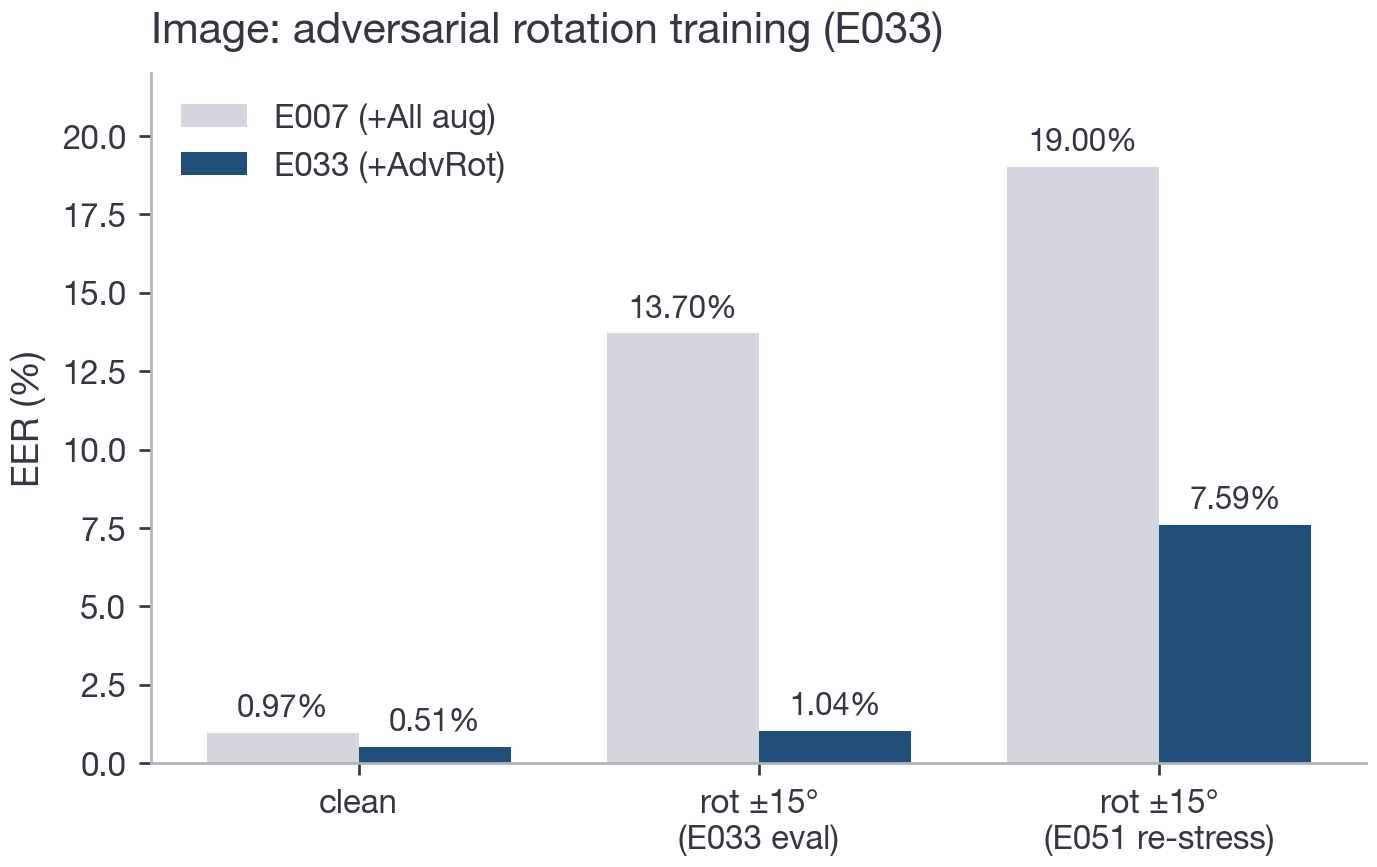

In [23]:
conds = ["clean", "rot ±15°\n(E033 eval)", "rot ±15°\n(E051 re-stress)"]
e007  = np.array([0.97, 13.70, 19.00])
e033  = np.array([0.51,  1.04,  7.59])
x     = np.arange(len(conds))
w     = 0.38

fig, ax = plt.subplots(figsize=(5.6, 3.2))
b1 = ax.bar(x - w/2, e007, w, label="E007 (+All aug)",
            color="#D3D7DD", edgecolor="none")
b2 = ax.bar(x + w/2, e033, w, label="E033 (+AdvRot)",
            color=C["blue"], edgecolor="none")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.35,
                f"{b.get_height():.2f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(conds)
ax.set_ylabel("EER (%)")
ax.set_title("Image: adversarial rotation training (E033)")
ax.legend(loc="upper left")
ax.set_ylim(0, 22)
save(fig, "fig2_adv_rot_robustness")
plt.show()

## Figure 3 — Audio: codec robustness (E052 codec augmentation)

Codec augmentation is a cleanly additive aug — zero clean-EER cost, −10 pp
under bandwidth-limited stress.

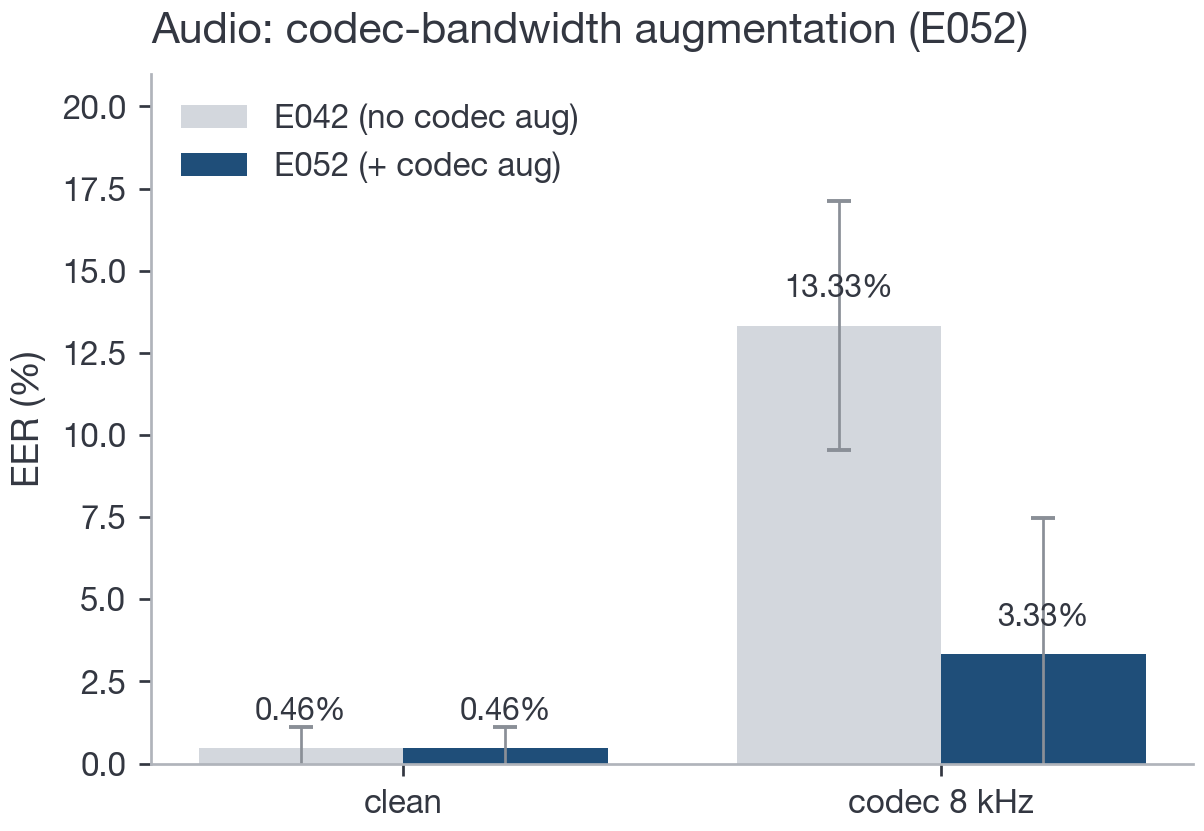

In [24]:
conds = ["clean", "codec 8 kHz"]
e042  = np.array([0.46, 13.33])
e052  = np.array([0.46,  3.33])
e042e = np.array([0.65,  3.79])
e052e = np.array([0.65,  4.14])
x     = np.arange(len(conds))
w     = 0.38

fig, ax = plt.subplots(figsize=(4.8, 3.2))
b1 = ax.bar(x - w/2, e042, w, yerr=e042e, label="E042 (no codec aug)",
            color="#D3D7DD", edgecolor="none",
            capsize=3, error_kw={"elinewidth": 0.7, "ecolor": "#8A8F97"})
b2 = ax.bar(x + w/2, e052, w, yerr=e052e, label="E052 (+ codec aug)",
            color=C["blue"], edgecolor="none",
            capsize=3, error_kw={"elinewidth": 0.7, "ecolor": "#8A8F97"})
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.7,
                f"{b.get_height():.2f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(conds)
ax.set_ylabel("EER (%)")
ax.set_title("Audio: codec-bandwidth augmentation (E052)")
ax.legend(loc="upper left")
ax.set_ylim(0, 21)
save(fig, "fig3_codec_robustness")
plt.show()

## Figure 4 — Experiment progression (flagship-moving steps only)

Log-scaled EER on the y-axis; each stream marks only the experiments that
actually moved its flagship number. 50× reduction for audio, ~9× for image,
~14× for fusion.

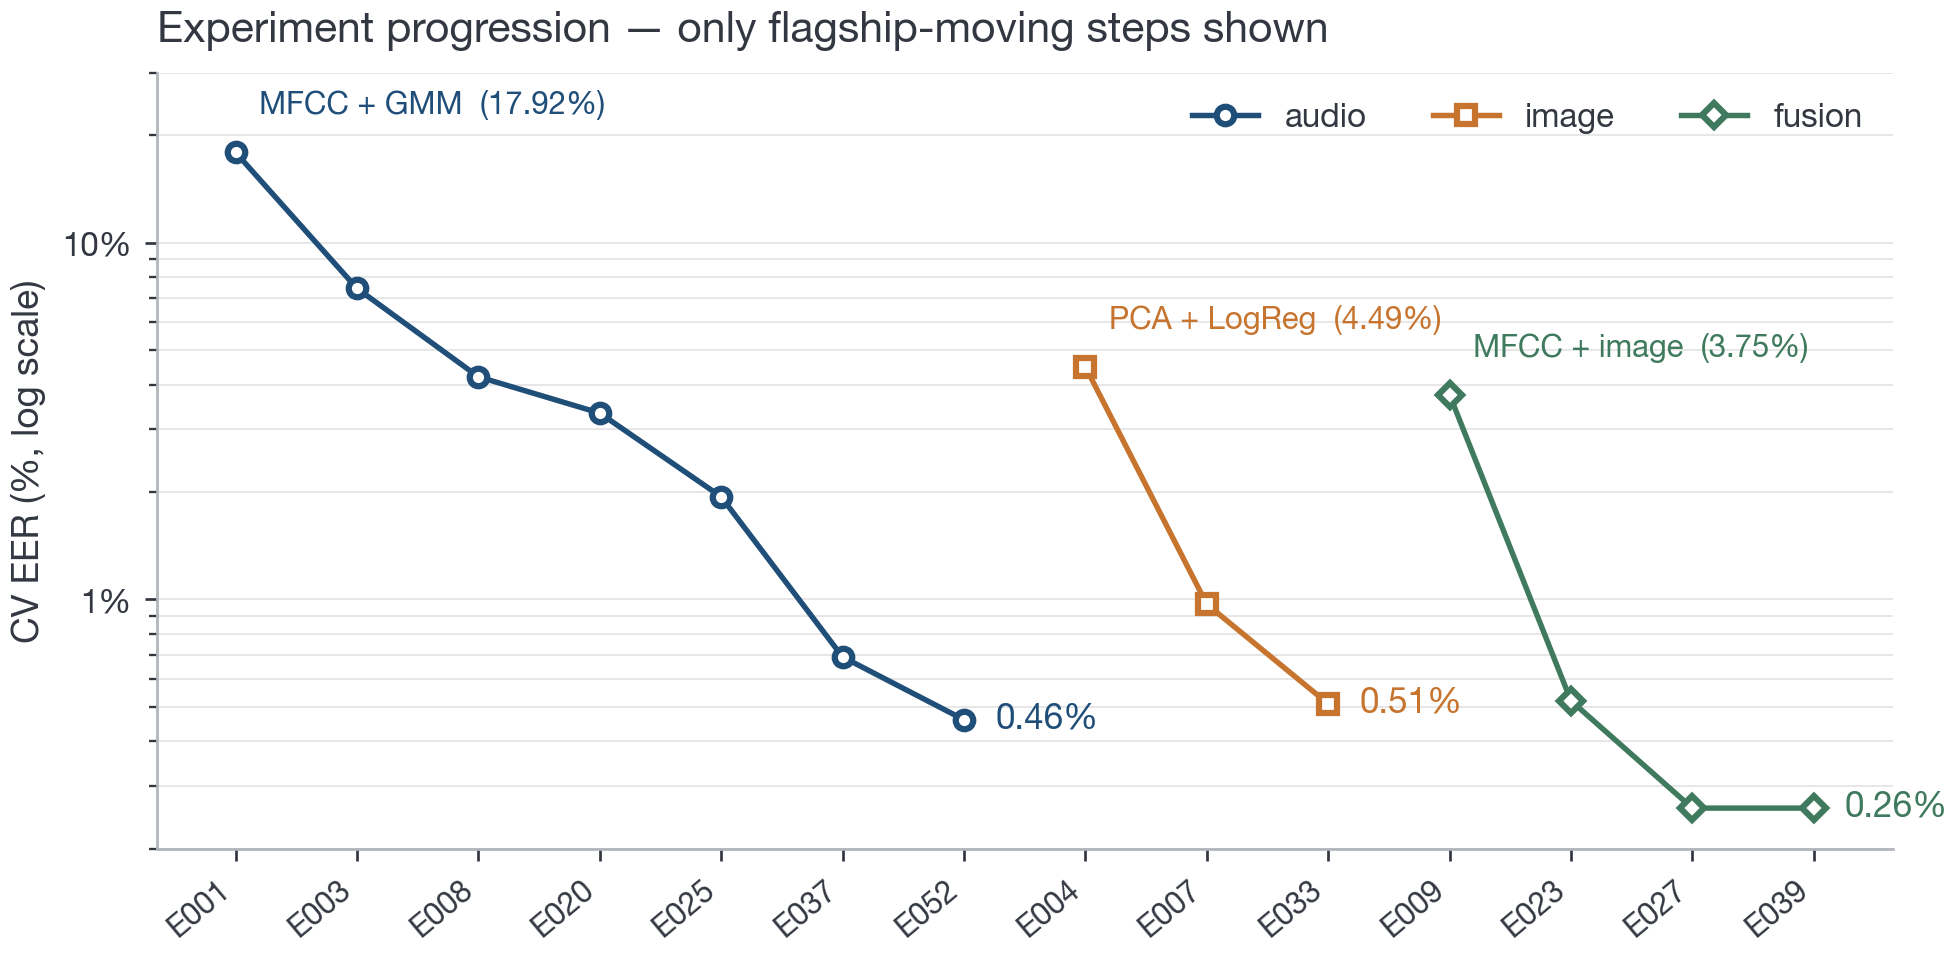

In [25]:
milestones = [
    ("audio",  "E001", "MFCC + GMM",             17.92),
    ("audio",  "E003", "+ UBM/MAP",               7.45),
    ("audio",  "E008", "+ aug",                   4.21),
    ("audio",  "E020", "LPCC",                    3.33),
    ("audio",  "E025", "+ pitch aug",             1.94),
    ("audio",  "E037", "+ tied cov",              0.69),
    ("audio",  "E052", "+ codec aug",             0.46),
    ("image",  "E004", "PCA + LogReg",            4.49),
    ("image",  "E007", "+ aug",                   0.97),
    ("image",  "E033", "+ adv-rot",               0.51),
    ("fusion", "E009", "MFCC + image",            3.75),
    ("fusion", "E023", "LPCC + image",            0.52),
    ("fusion", "E027", "trimodal",                0.26),
    ("fusion", "E039", "trimodal (E037/E033)",    0.26),
]

fig, ax = plt.subplots(figsize=(8.0, 3.6))
col = {"audio": C["blue"], "image": C["orange"], "fusion": C["green"]}
mk  = {"audio": "o",       "image": "s",         "fusion": "D"}

for stream in ["audio", "image", "fusion"]:
    pts = [m for m in milestones if m[0] == stream]
    xs  = np.arange(len(milestones))
    idx = [i for i, m in enumerate(milestones) if m[0] == stream]
    ax.plot(idx, [pts[j][3] for j in range(len(pts))],
            linestyle="-", marker=mk[stream], color=col[stream],
            markerfacecolor="white", markeredgewidth=1.6, label=stream)

# Endpoint annotations: start + end of each stream only, bold final EER.
for stream in ["audio", "image", "fusion"]:
    pts = [(i, m) for i, m in enumerate(milestones) if m[0] == stream]
    i0, m0 = pts[0]
    i1, m1 = pts[-1]
    ax.annotate(f"{m0[2]}  ({m0[3]:.2f}%)", (i0, m0[3]),
                xytext=(6, 10), textcoords="offset points",
                fontsize=8, color=col[stream])
    ax.annotate(f"{m1[3]:.2f}%", (i1, m1[3]),
                xytext=(8, -2), textcoords="offset points",
                fontsize=9, color=col[stream], fontweight="bold")

ax.set_yscale("log")
ax.set_ylabel("CV EER (%, log scale)")
ax.set_xticks(range(len(milestones)))
ax.set_xticklabels([m[1] for m in milestones], rotation=40, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylim(0.2, 30)
ax.grid(axis="y", which="both", color="#ddd", linewidth=0.5, alpha=0.7)
ax.set_title("Experiment progression — only flagship-moving steps shown")
ax.legend(loc="upper right", ncol=3)
save(fig, "fig4_progression")
plt.show()

## Figure 5 — Fusion evolution

Each bar is a fusion iteration's OOF EER. Trimodal halves bimodal, and the
flagship (E039) hits 0/222 errors on the cross-validation pool.

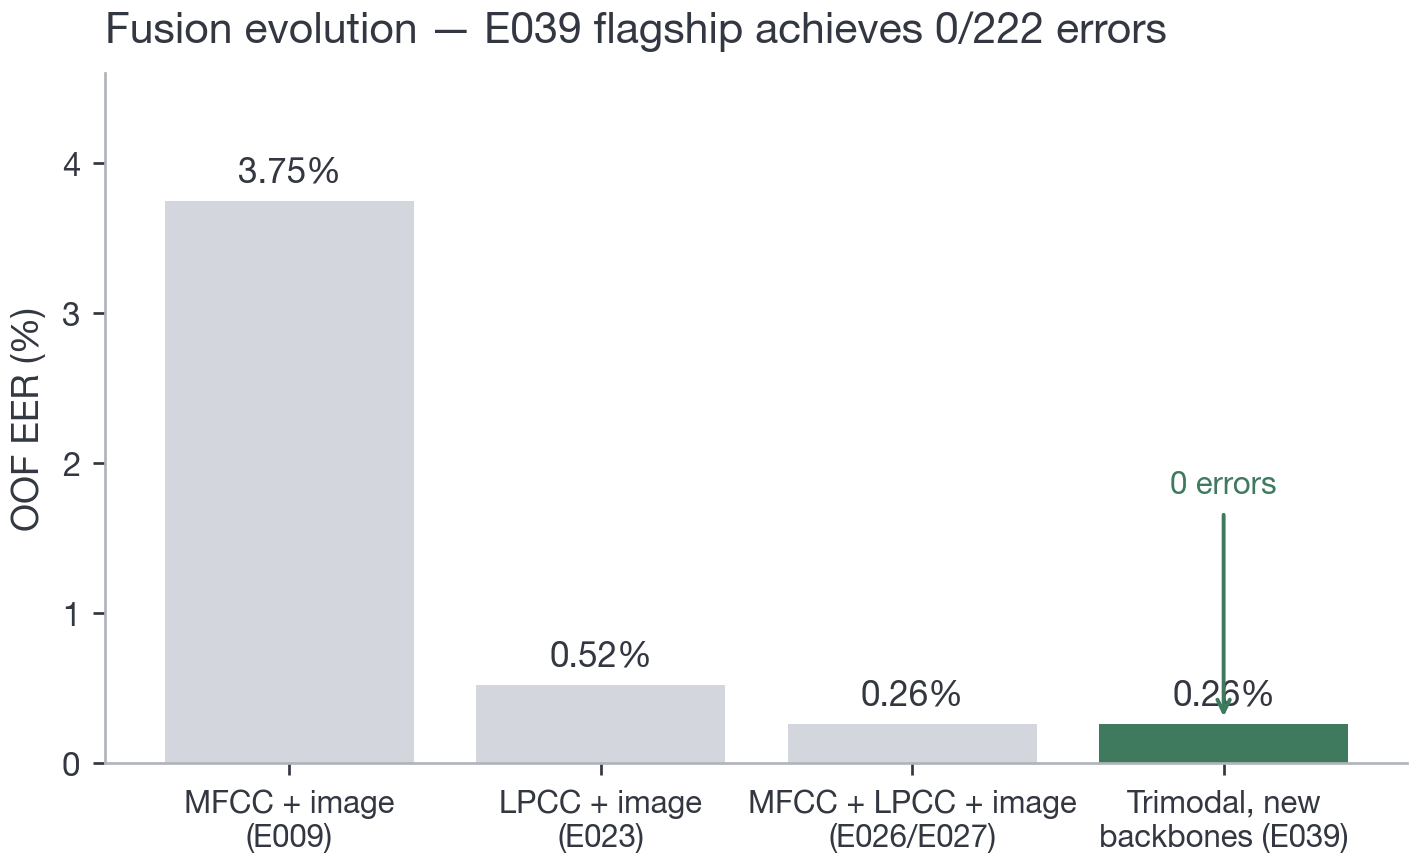

In [26]:
labels = ["MFCC + image\n(E009)", "LPCC + image\n(E023)",
          "MFCC + LPCC + image\n(E026/E027)", "Trimodal, new\nbackbones (E039)"]
oof    = np.array([3.75, 0.52, 0.26, 0.26])
colors = ["#D3D7DD", "#D3D7DD", "#D3D7DD", C["green"]]

fig, ax = plt.subplots(figsize=(6.0, 3.2))
bars = ax.bar(range(len(labels)), oof, color=colors, edgecolor="none")
for b, v in zip(bars, oof):
    ax.text(b.get_x() + b.get_width()/2, v + 0.08, f"{v:.2f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("OOF EER (%)")
ax.set_title("Fusion evolution — E039 flagship achieves 0/222 errors")
ax.set_ylim(0, 4.6)
ax.annotate("0 errors", xy=(3, 0.26), xytext=(3, 1.8),
            fontsize=8, color=C["green"], ha="center",
            arrowprops={"arrowstyle": "->", "color": C["green"], "linewidth": 1.0})
save(fig, "fig5_fusion_evolution")
plt.show()

## OOF pipeline — required for Figures 6 & 7

Reuses `predict_fusion.py` helpers verbatim. Heavy on first run; cached to
`cache/oof_scores.pkl`.

In [27]:
OOF_CACHE = CACHE / "oof_scores.pkl"


def compute_oof_scores():
    import predict_fusion as pf
    from src.data.splits import load_manifest, iter_folds_loso

    manifest = load_manifest(REPO / "data")
    y_all    = manifest["label"].to_numpy()
    n        = len(manifest)
    oof_m    = np.full(n, np.nan)
    oof_l    = np.full(n, np.nan)
    oof_i    = np.full(n, np.nan)

    for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=pf.SEED):
        seed_f   = pf.SEED + fold_id
        train_df = manifest.loc[train_idx]
        val_df   = manifest.loc[val_idx]
        print(f"  fold {fold_id}...")
        ubm_m, ad_m = pf._train_mfcc(train_df, REPO / "data", augment=True, seed=seed_f)
        ubm_l, ad_l = pf._train_lpcc(train_df, REPO / "data", augment=True, seed=seed_f)
        scaler, pca, clf = pf._train_image(train_df, REPO / "data", augment=True, seed=seed_f)
        for idx, row in val_df.iterrows():
            oof_m[idx] = pf._score_mfcc(pf._find_wav(row["stem"], REPO / "data"), ad_m, ubm_m)
            oof_l[idx] = pf._score_lpcc(pf._find_wav(row["stem"], REPO / "data"), ad_l, ubm_l)
            oof_i[idx] = pf._score_image(pf._find_png(row["stem"], REPO / "data"), scaler, pca, clf)

    cal_m = pf._fit_calibrator(oof_m, y_all)
    cal_l = pf._fit_calibrator(oof_l, y_all)
    cal_i = pf._fit_calibrator(oof_i, y_all)
    cal_mo = cal_m.decision_function(oof_m.reshape(-1, 1))
    cal_lo = cal_l.decision_function(oof_l.reshape(-1, 1))
    cal_io = cal_i.decision_function(oof_i.reshape(-1, 1))

    best = (np.inf, None)
    for w_m in np.linspace(0, 1, 51):
        for w_l in np.linspace(0, 1 - w_m, 51):
            w_i = 1 - w_m - w_l
            fused = w_m * cal_mo + w_l * cal_lo + w_i * cal_io
            eer, _ = pf.compute_eer(fused[y_all == 1], fused[y_all == 0])
            if eer < best[0]:
                best = (eer, (w_m, w_l, w_i))
    w_m, w_l, w_i = best[1]
    fused = w_m * cal_mo + w_l * cal_lo + w_i * cal_io
    print(f"  weights: mfcc={w_m:.2f}  lpcc={w_l:.2f}  image={w_i:.2f}  OOF EER={best[0]*100:.2f}%")

    return {"mfcc": cal_mo, "lpcc": cal_lo, "image": cal_io,
            "fusion": fused, "y": y_all, "weights": (w_m, w_l, w_i)}


if OOF_CACHE.exists():
    print(f"[oof] loading cached {OOF_CACHE}")
    scores = pickle.load(open(OOF_CACHE, "rb"))
else:
    print("[oof] no cache — training full OOF pipeline (~5 min)")
    scores = compute_oof_scores()
    pickle.dump(scores, open(OOF_CACHE, "wb"))

print(f"fusion weights: {scores['weights']}")

[oof] loading cached /Users/ramsay/school/sur/project/cache/oof_scores.pkl
fusion weights: (np.float64(0.0), np.float64(0.46), np.float64(0.54))


## Figure 6 — DET curve (OOF)

Standard speaker-verification visualization: miss rate vs false-alarm rate
on probit-warped axes. The flagship fusion achieves 0 errors across all 222
OOF trials (star at corner).

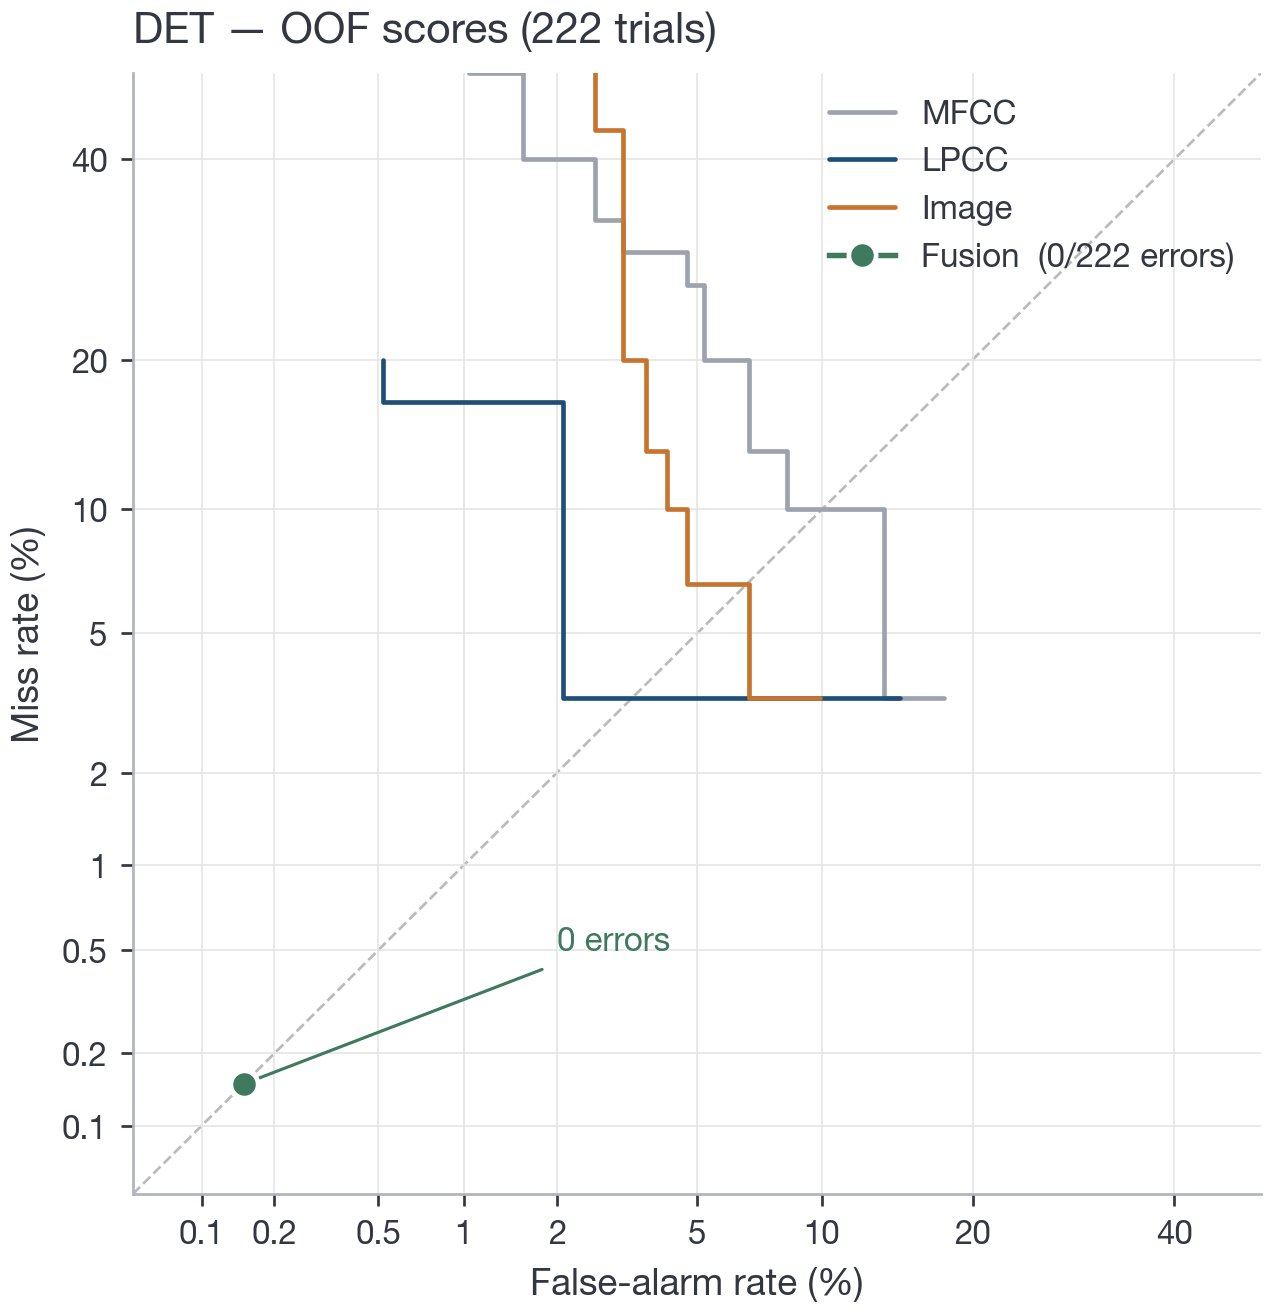

In [28]:
def det_axes(ax):
    ticks = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4]
    labs  = ["0.1", "0.2", "0.5", "1", "2", "5", "10", "20", "40"]
    ax.set_xticks([norm.ppf(t) for t in ticks]); ax.set_xticklabels(labs)
    ax.set_yticks([norm.ppf(t) for t in ticks]); ax.set_yticklabels(labs)
    lo, hi = norm.ppf(0.0005), norm.ppf(0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.plot([lo, hi], [lo, hi], "--", color="#bbb", linewidth=0.7, zorder=0)
    ax.set_xlabel("False-alarm rate (%)")
    ax.set_ylabel("Miss rate (%)")
    ax.grid(which="both", color="#e3e3e3", linewidth=0.5, alpha=0.8)


def det_points(s_tar, s_non):
    y   = np.r_[np.ones_like(s_tar), np.zeros_like(s_non)]
    s   = np.r_[s_tar, s_non]
    fpr, tpr, _ = roc_curve(y, s)
    far, frr    = fpr, 1.0 - tpr
    m = (far > 0) & (far < 1) & (frr > 0) & (frr < 1)
    return norm.ppf(far[m]), norm.ppf(frr[m])


streams = [
    ("MFCC",   scores["mfcc"],   C["grey"]),
    ("LPCC",   scores["lpcc"],   C["blue"]),
    ("Image",  scores["image"],  C["orange"]),
    ("Fusion", scores["fusion"], C["green"]),
]
y = scores["y"]

fig, ax = plt.subplots(figsize=(5.2, 5.2))
det_axes(ax)
for name, s, c in streams:
    xx, yy = det_points(s[y == 1], s[y == 0])
    lw = 2.0 if name == "Fusion" else 1.2
    if len(xx) == 0:
        # Subtle filled marker + call-out arrow instead of a tacky star.
        x0, y0 = norm.ppf(0.0015), norm.ppf(0.0015)
        ax.plot(x0, y0, marker="o", markersize=7, color=c,
                markeredgecolor="white", markeredgewidth=1.2,
                label=f"{name}  (0/222 errors)", zorder=5)
        ax.annotate("0 errors",
                    xy=(x0, y0),
                    xytext=(norm.ppf(0.02), norm.ppf(0.005)),
                    fontsize=8.5, color=c,
                    arrowprops={"arrowstyle": "-", "color": c,
                                 "linewidth": 0.8, "shrinkA": 3, "shrinkB": 3})
    else:
        ax.plot(xx, yy, color=c, linewidth=lw, label=name, solid_capstyle="round")
ax.set_title("DET — OOF scores (222 trials)")
ax.legend(loc="upper right", handlelength=2.0, borderaxespad=0.4)
save(fig, "fig6_det_curve")
plt.show()

## Figure 7 — Fused OOF score distribution

Calibrated log-odds for all 222 OOF trials. Zero overlap at the Bayes
threshold (0.5 prior ↔ log-odds = 0) — the visual proof of the 0/222 result.

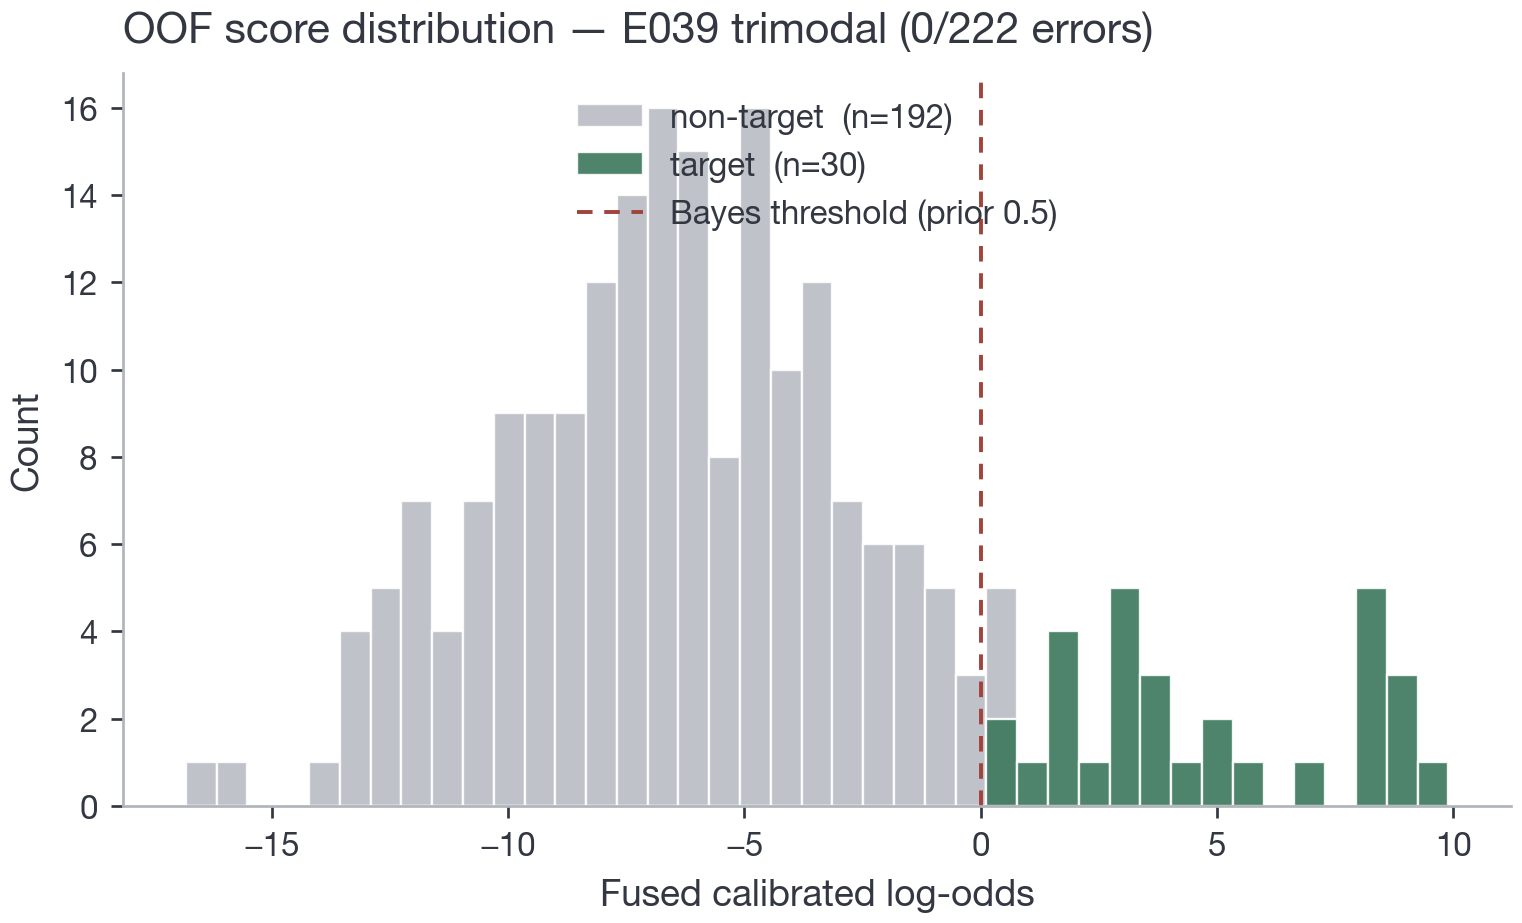

In [29]:
fused = scores["fusion"]
y     = scores["y"]
tar   = fused[y == 1]
non   = fused[y == 0]

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bins = np.linspace(min(fused.min(), -5), max(fused.max(), 5), 42)
ax.hist(non, bins=bins, color="#B8BDC4", alpha=0.90, edgecolor="white",
        linewidth=0.6, label=f"non-target  (n={len(non)})")
ax.hist(tar, bins=bins, color=C["green"], alpha=0.92, edgecolor="white",
        linewidth=0.6, label=f"target  (n={len(tar)})")
ax.axvline(0, color=C["red"], linestyle=(0, (4, 3)), linewidth=1.0,
           label="Bayes threshold (prior 0.5)")
ax.set_xlabel("Fused calibrated log-odds")
ax.set_ylabel("Count")
ax.set_title("OOF score distribution — E039 trimodal (0/222 errors)")
ax.legend(loc="upper center")
save(fig, "fig7_score_histogram")
plt.show()

In [30]:
print("All figures written to", FIG)

All figures written to /Users/ramsay/school/sur/project/docs/figures
